#  DeepIctal-Bonn: LSTM Epileptic Seizure Detection

End-to-end pipeline: load Bonn EEG data → window for LSTM → train → evaluate.
Documentation (README / LaTeX report) is generated separately by `generate_docs.py`.

## 0. Imports & Configuration

In [ ]:
import os
import glob
import json
import platform
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import welch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score, precision_score, recall_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers

warnings.filterwarnings("ignore")

In [2]:
SEED = 21
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
REPORT_DIR = os.path.join(PROJECT_ROOT, "reports")

for d in (FIG_DIR, MODEL_DIR, REPORT_DIR):
    os.makedirs(d, exist_ok=True)

# Acquisition parameters (Bonn University EEG dataset)
FS = 173.61
SIGNAL_LEN = 4097
WINDOW_LEN = 178
N_WINDOWS = 23
CROP_LEN = N_WINDOWS * WINDOW_LEN          # 4094
N_OFFSETS = SIGNAL_LEN - CROP_LEN          # 3 -> 4 crop offsets (0..3)

# Class mapping (set "S" = ictal/seizure; Z, O, N, F = normal/interictal)
CLASS_1_SETS = ["S"]
CLASS_0_SETS = ["Z", "O", "N", "F"]

# Recall is the priority metric for this task (missed seizures are costly);
# the decision threshold is tuned on the validation set to hit this target.
TARGET_RECALL = 0.90

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300

CLASS_COLORS = {0: "#3B82C4", 1: "#D64545"}
CLASS_NAMES = {0: "Normal / Interictal", 1: "Ictal / Seizure"}

print(f"TensorFlow {tf.__version__} | seed={SEED} | target recall={TARGET_RECALL}")

TensorFlow 2.21.0 | seed=21 | target recall=0.9


## 1. Data Loading

In [3]:
def load_bonn_dataset(data_dir):
    records, rec_id = [], 0
    for set_name in ["Z", "O", "N", "F", "S"]:
        files = sorted(glob.glob(os.path.join(data_dir, set_name, "*")))
        files = [f for f in files if f.lower().endswith(".txt")]
        if not files:
            raise FileNotFoundError(f"No recordings found for set '{set_name}' in {data_dir}")
        for fp in files:
            sig = np.loadtxt(fp).astype(np.float32)
            if sig.shape[0] != SIGNAL_LEN:
                warnings.warn(f"{fp}: {sig.shape[0]} points (expected {SIGNAL_LEN}), skipping.")
                continue
            records.append({
                "recording_id": rec_id, "set": set_name, "signal": sig,
                "label": 1 if set_name in CLASS_1_SETS else 0,
            })
            rec_id += 1
    return records


records = load_bonn_dataset(DATA_DIR)
meta_df = pd.DataFrame([{k: v for k, v in r.items() if k != "signal"} for r in records])
print(f"Loaded {len(records)} recordings.")
print(meta_df.groupby(["set", "label"]).size())

Loaded 500 recordings.
set  label
F    0        100
N    0        100
O    0        100
S    1        100
Z    0        100
dtype: int64


## 2. Exploratory Data Analysis

### 2.1 Class Distribution

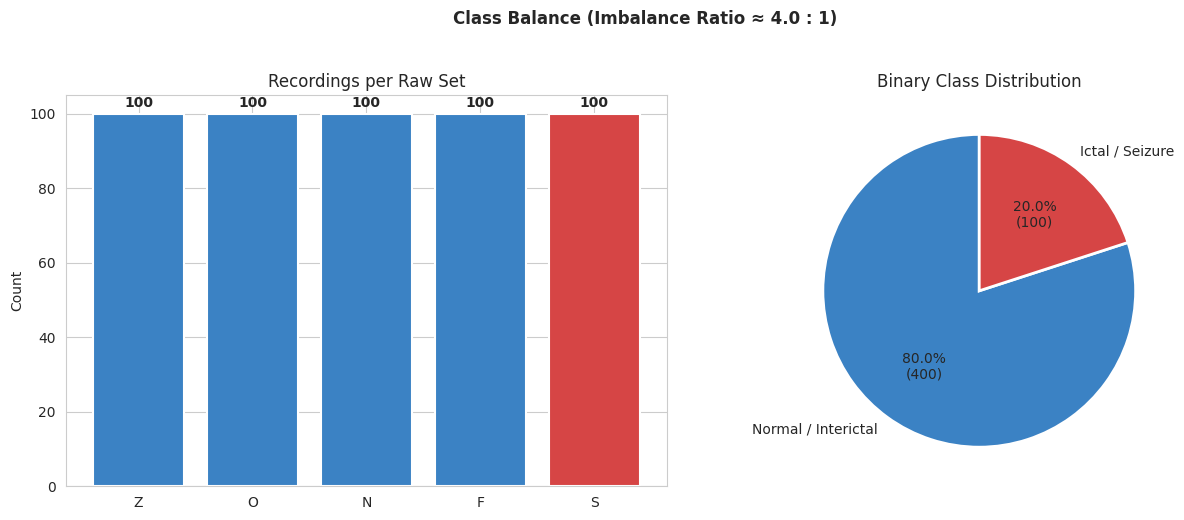

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

set_counts = meta_df["set"].value_counts().reindex(["Z", "O", "N", "F", "S"])
bar_colors = [CLASS_COLORS[1] if s in CLASS_1_SETS else CLASS_COLORS[0] for s in set_counts.index]
axes[0].bar(set_counts.index, set_counts.values, color=bar_colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Recordings per Raw Set")
axes[0].set_ylabel("Count")
for i, v in enumerate(set_counts.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

label_counts = meta_df["label"].value_counts().sort_index()
axes[1].pie(
    label_counts.values, labels=[CLASS_NAMES[i] for i in label_counts.index],
    colors=[CLASS_COLORS[i] for i in label_counts.index],
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * sum(label_counts.values) / 100))})",
    startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2),
)
axes[1].set_title("Binary Class Distribution")

ratio = label_counts[0] / label_counts[1]
fig.suptitle(f"Class Balance (Imbalance Ratio ≈ {ratio:.1f} : 1)", fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()

### 2.2 Time-Domain Comparison

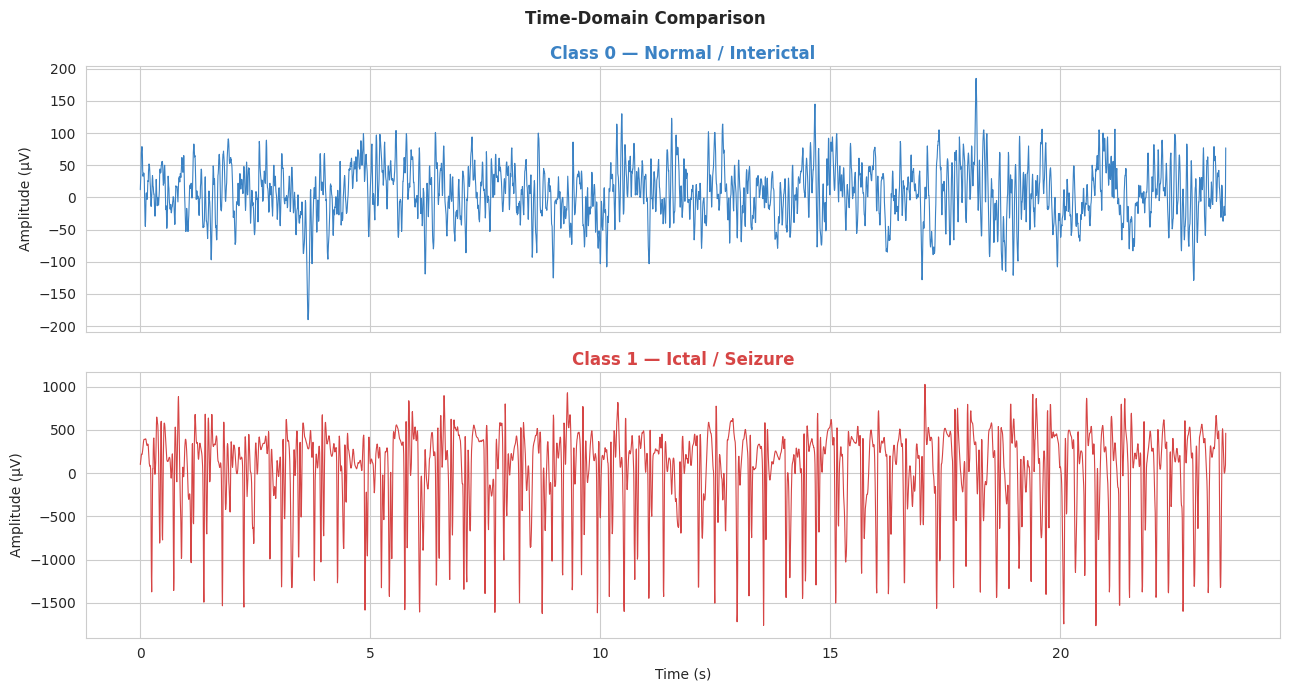

In [5]:
sig0 = next(r["signal"] for r in records if r["label"] == 0 and r["set"] == "Z")
sig1 = next(r["signal"] for r in records if r["label"] == 1)
t = np.arange(SIGNAL_LEN) / FS

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(t, sig0, color=CLASS_COLORS[0], linewidth=0.8)
axes[0].set_title(f"Class 0 — {CLASS_NAMES[0]}", color=CLASS_COLORS[0], fontweight="bold")
axes[0].set_ylabel("Amplitude (µV)")

axes[1].plot(t, sig1, color=CLASS_COLORS[1], linewidth=0.8)
axes[1].set_title(f"Class 1 — {CLASS_NAMES[1]}", color=CLASS_COLORS[1], fontweight="bold")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].set_xlabel("Time (s)")

fig.suptitle("Time-Domain Comparison", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "time_domain_comparison.png"), bbox_inches="tight")
plt.show()

### 2.3 Frequency-Domain (Welch PSD)

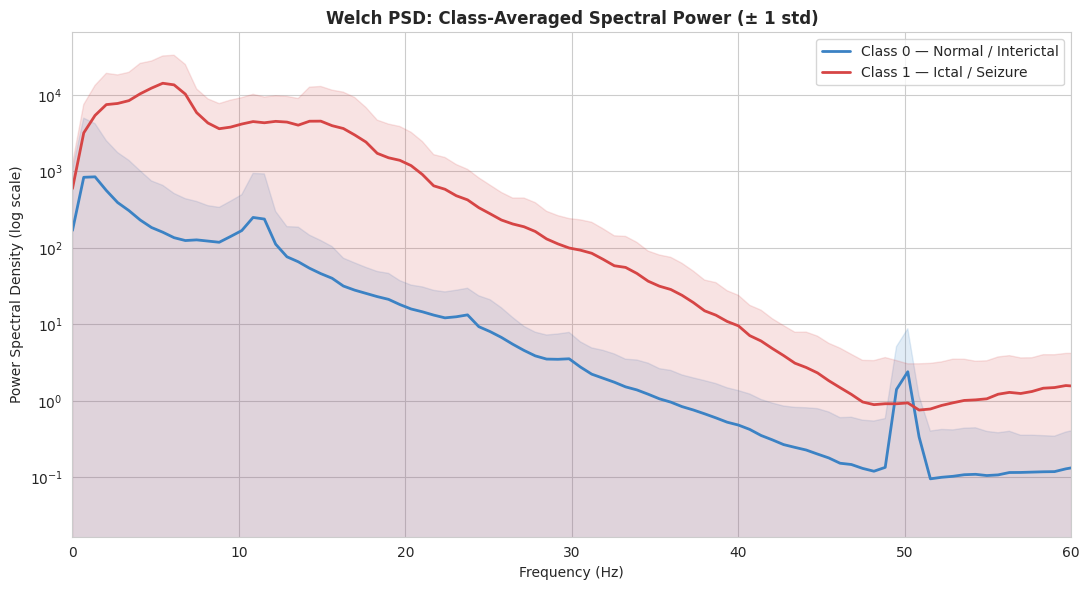

In [6]:
def mean_psd(sig_list, fs=FS, nperseg=256):
    psds = [welch(s, fs=fs, nperseg=nperseg)[1] for s in sig_list]
    f, _ = welch(sig_list[0], fs=fs, nperseg=nperseg)
    return f, np.mean(psds, axis=0), np.std(psds, axis=0)


sigs_0 = [r["signal"] for r in records if r["label"] == 0]
sigs_1 = [r["signal"] for r in records if r["label"] == 1]
f0, psd0_mean, psd0_std = mean_psd(sigs_0)
f1, psd1_mean, psd1_std = mean_psd(sigs_1)

fig, ax = plt.subplots(figsize=(11, 6))
ax.semilogy(f0, psd0_mean, color=CLASS_COLORS[0], label=f"Class 0 — {CLASS_NAMES[0]}", linewidth=2)
ax.fill_between(f0, psd0_mean - psd0_std, psd0_mean + psd0_std, color=CLASS_COLORS[0], alpha=0.15)
ax.semilogy(f1, psd1_mean, color=CLASS_COLORS[1], label=f"Class 1 — {CLASS_NAMES[1]}", linewidth=2)
ax.fill_between(f1, psd1_mean - psd1_std, psd1_mean + psd1_std, color=CLASS_COLORS[1], alpha=0.15)
ax.set_xlim(0, 60)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (log scale)")
ax.set_title("Welch PSD: Class-Averaged Spectral Power (± 1 std)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "psd_comparison.png"), bbox_inches="tight")
plt.show()

## 3. Windowing, Grouped Splitting & Scaling

Each 4097-point signal is reshaped into `(23, 178)` — 23 timesteps of a
178-point window each — so the LSTM unrolls 23 steps instead of 4097,
avoiding vanishing gradients. The 3 leftover points per signal give 4
valid crop offsets, which we use to quadruple the dataset. All crops from
the same recording are kept in the same split (grouped, no leakage).

In [7]:
def build_windowed_tensor(records):
    X, y, groups = [], [], []
    for r in records:
        sig = r["signal"]
        for offset in range(N_OFFSETS + 1):
            crop = sig[offset: offset + CROP_LEN]
            X.append(crop.reshape(N_WINDOWS, WINDOW_LEN))
            y.append(r["label"])
            groups.append(r["recording_id"])
    return (np.stack(X).astype(np.float32), np.array(y, dtype=np.int32), np.array(groups, dtype=np.int32))


X_all, y_all, groups_all = build_windowed_tensor(records)
print(f"Tensor shape: {X_all.shape}  (Samples, Time_Steps, Features)")
assert X_all.shape[1:] == (N_WINDOWS, WINDOW_LEN)

Tensor shape: (2000, 23, 178)  (Samples, Time_Steps, Features)


In [8]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(X_all, y_all, groups=groups_all))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(gss2.split(X_all[temp_idx], y_all[temp_idx], groups=groups_all[temp_idx]))
val_idx, test_idx = temp_idx[val_rel_idx], temp_idx[test_rel_idx]

X_train, y_train, g_train = X_all[train_idx], y_all[train_idx], groups_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

assert not (set(g_train) & set(groups_all[val_idx]))
assert not (set(g_train) & set(groups_all[test_idx]))
assert not (set(groups_all[val_idx]) & set(groups_all[test_idx]))

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print("No recording leaks across splits.")

Train: (1400, 23, 178) | Val: (300, 23, 178) | Test: (300, 23, 178)
No recording leaks across splits.


In [9]:
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, WINDOW_LEN))


def scale_tensor(X):
    n, t, f = X.shape
    return scaler.transform(X.reshape(-1, f)).reshape(n, t, f).astype(np.float32)


X_train_s, X_val_s, X_test_s = scale_tensor(X_train), scale_tensor(X_val), scale_tensor(X_test)

## 4. Class Imbalance Handling

In [10]:
class_weight_values = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(np.unique(y_train), class_weight_values)}
print(f"Class weights: {class_weight_dict}")

Class weights: {0: 0.6272401433691757, 1: 2.464788732394366}


## 5. LSTM Model

In [11]:
def build_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True, kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.35),
        layers.LSTM(32, kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.35),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="DeepIctal_LSTM")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")],
    )
    return model


model = build_model((N_WINDOWS, WINDOW_LEN))
model.summary()

with open(os.path.join(REPORT_DIR, "model_summary.txt"), "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

Model: "DeepIctal_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 23, 64)         │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 23, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,553 (295.13 KB)

 Trainable params: 75,361 (294.38 KB)

 Non-trainable params: 192 (768.00 B)

## 6. Training

In [12]:
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=150, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)

model.save(os.path.join(MODEL_DIR, "deepictal_lstm.keras"))

Epoch 1/150


44/44 - 5s - 104ms/step - accuracy: 0.7614 - auc: 0.8455 - loss: 0.5166 - precision: 0.4490 - recall: 0.7746 - val_accuracy: 0.9567 - val_auc: 0.9794 - val_loss: 0.5022 - val_precision: 0.9365 - val_recall: 0.8676 - learning_rate: 0.0010


Epoch 2/150


44/44 - 1s - 14ms/step - accuracy: 0.9071 - auc: 0.9803 - loss: 0.2393 - precision: 0.6954 - recall: 0.9648 - val_accuracy: 0.9600 - val_auc: 0.9942 - val_loss: 0.3165 - val_precision: 0.9375 - val_recall: 0.8824 - learning_rate: 0.0010


Epoch 3/150


...

44/44 - 1s - 14ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0309 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9833 - val_auc: 0.9994 - val_loss: 0.0701 - val_precision: 0.9701 - val_recall: 0.9559 - learning_rate: 2.5000e-04


Epoch 27/150


44/44 - 1s - 30ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0314 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9833 - val_auc: 0.9994 - val_loss: 0.0661 - val_precision: 0.9701 - val_recall: 0.9559 - learning_rate: 2.5000e-04


Epoch 27: early stopping


Restoring model weights from the end of the best epoch: 12.


## 7. Training Curves

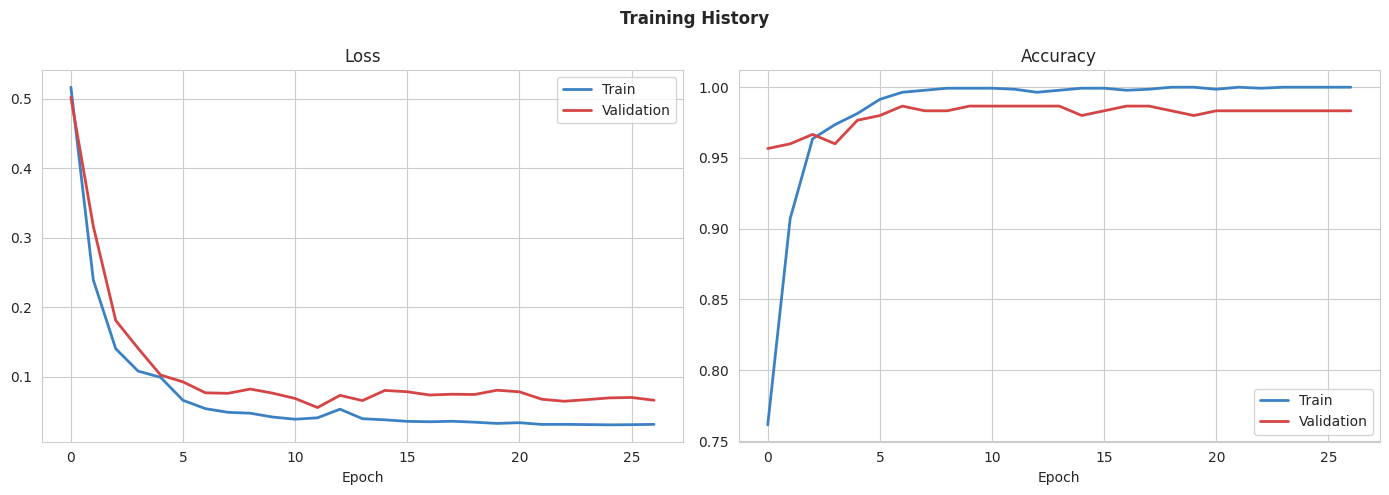

In [13]:
hist_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df["loss"], label="Train", color=CLASS_COLORS[0], linewidth=2)
axes[0].plot(hist_df["val_loss"], label="Validation", color=CLASS_COLORS[1], linewidth=2)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist_df["accuracy"], label="Train", color=CLASS_COLORS[0], linewidth=2)
axes[1].plot(hist_df["val_accuracy"], label="Validation", color=CLASS_COLORS[1], linewidth=2)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

fig.suptitle("Training History", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_curves.png"), bbox_inches="tight")
plt.show()

## 8. Evaluation

The default 0.5 threshold is reported for reference, but the deployed
operating point is chosen by tuning the threshold on the **validation**
set to guarantee recall ≥ 90% (the priority metric for seizure screening),
then applying that fixed threshold to the held-out test set.

In [14]:
y_val_proba = model.predict(X_val_s, verbose=0).ravel()
y_test_proba = model.predict(X_test_s, verbose=0).ravel()
test_auc = roc_auc_score(y_test, y_test_proba)


def metrics_at_threshold(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    return {
        "threshold": float(thr),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1_score": float(f1_score(y_true, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
    }


default_metrics = metrics_at_threshold(y_test, y_test_proba, 0.5)

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
valid = recalls[:-1] >= TARGET_RECALL
tuned_threshold = float(thresholds[valid][np.argmax(precisions[:-1][valid])]) if valid.any() else 0.5
tuned_metrics = metrics_at_threshold(y_test, y_test_proba, tuned_threshold)

print(f"ROC-AUC: {test_auc:.4f}")
print(f"Default @0.5           -> {default_metrics}")
print(f"Tuned  @{tuned_threshold:.4f} (recall>={TARGET_RECALL}) -> {tuned_metrics}")

report_str = classification_report(
    y_test, (y_test_proba >= tuned_threshold).astype(int),
    target_names=[CLASS_NAMES[0], CLASS_NAMES[1]], zero_division=0,
)
print("\nClassification Report (tuned threshold):\n", report_str)
with open(os.path.join(REPORT_DIR, "classification_report.txt"), "w") as f:
    f.write(report_str)

ROC-AUC: 0.9977
Default @0.5           -> {'threshold': 0.5, 'accuracy': 0.97, 'precision': 0.8823529411764706, 'recall': 0.9375, 'f1_score': 0.9090909090909091, 'confusion_matrix': [[246, 6], [3, 45]]}
Tuned  @0.9127 (recall>=0.9) -> {'threshold': 0.9126864671707153, 'accuracy': 0.97, 'precision': 0.8979591836734694, 'recall': 0.9166666666666666, 'f1_score': 0.9072164948453608, 'confusion_matrix': [[247, 5], [4, 44]]}

Classification Report (tuned threshold):
                      precision    recall  f1-score   support

Normal / Interictal       0.98      0.98      0.98       252
    Ictal / Seizure       0.90      0.92      0.91        48

           accuracy                           0.97       300
          macro avg       0.94      0.95      0.94       300
       weighted avg       0.97      0.97      0.97       300



### 8.1 Precision–Recall Curve & Chosen Threshold

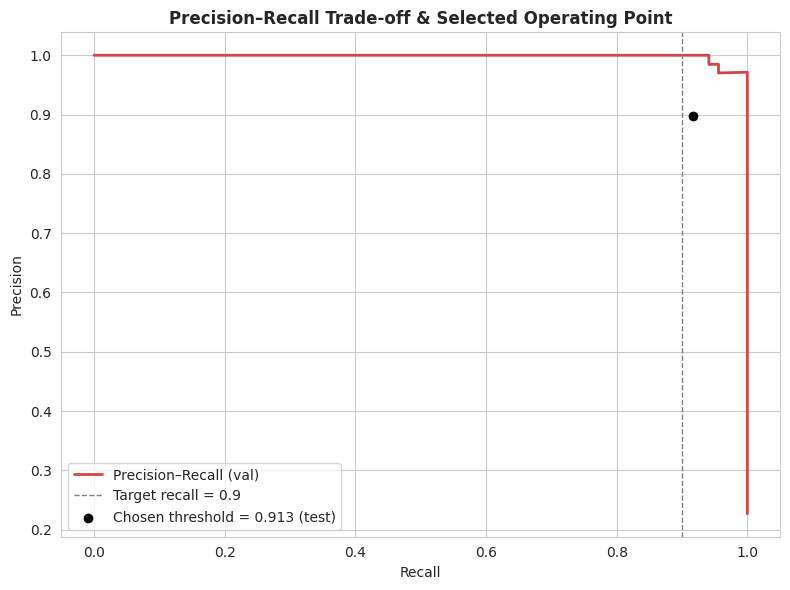

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recalls, precisions, color=CLASS_COLORS[1], linewidth=2, label="Precision–Recall (val)")
ax.axvline(TARGET_RECALL, color="gray", linestyle="--", linewidth=1, label=f"Target recall = {TARGET_RECALL}")
ax.scatter([tuned_metrics["recall"]], [tuned_metrics["precision"]], color="black", zorder=5,
           label=f"Chosen threshold = {tuned_threshold:.3f} (test)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Trade-off & Selected Operating Point", fontweight="bold")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "precision_recall_curve.png"), bbox_inches="tight")
plt.show()

### 8.2 Confusion Matrix (Tuned Threshold)

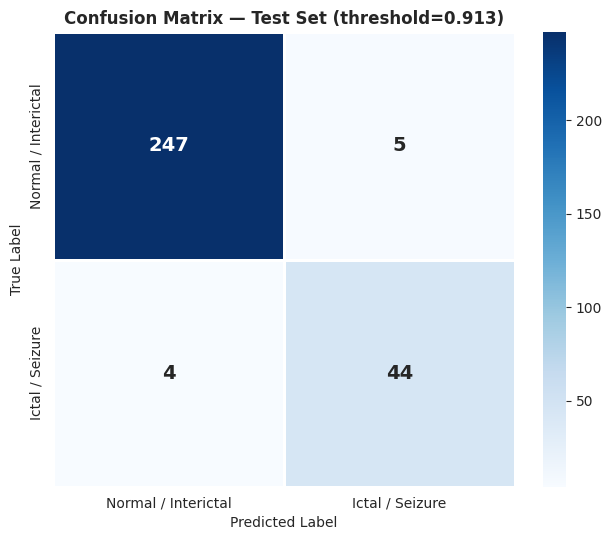

In [16]:
cm = np.array(tuned_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=1, linecolor="white",
    xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]], yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
    annot_kws={"fontsize": 14, "fontweight": "bold"},
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Confusion Matrix — Test Set (threshold={tuned_threshold:.3f})", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "confusion_matrix.png"), bbox_inches="tight")
plt.show()

### 8.3 ROC Curve

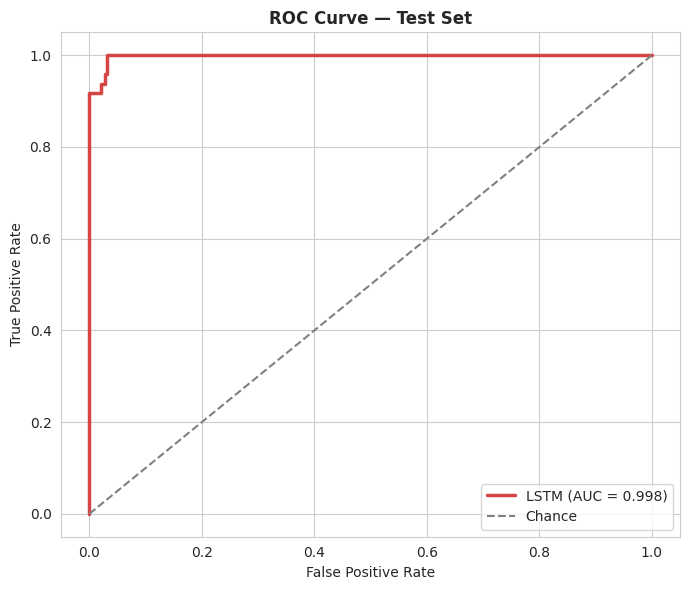

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=CLASS_COLORS[1], linewidth=2.5, label=f"LSTM (AUC = {test_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "roc_curve.png"), bbox_inches="tight")
plt.show()

## 9. Save Results Summary

All numbers are serialized to `reports/results.json` for `generate_docs.py`
to consume when building the README and LaTeX report.

In [18]:
results_summary = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "seed": SEED,
    "python_version": platform.python_version(),
    "tensorflow_version": tf.__version__,
    "dataset": {
        "n_recordings": len(records),
        "n_windowed_samples": int(X_all.shape[0]),
        "tensor_shape": list(X_all.shape),
        "class_0_sets": CLASS_0_SETS,
        "class_1_sets": CLASS_1_SETS,
        "class_0_count_recordings": int((meta_df["label"] == 0).sum()),
        "class_1_count_recordings": int((meta_df["label"] == 1).sum()),
        "imbalance_ratio": float(ratio),
        "n_train": int(X_train.shape[0]),
        "n_val": int(X_val.shape[0]),
        "n_test": int(X_test.shape[0]),
    },
    "windowing": {
        "signal_len": SIGNAL_LEN, "n_windows": N_WINDOWS, "window_len": WINDOW_LEN,
        "crop_len": CROP_LEN, "n_offsets": N_OFFSETS + 1, "sampling_rate_hz": FS,
    },
    "class_weights": class_weight_dict,
    "training": {
        "epochs_run": len(hist_df),
        "final_train_loss": float(hist_df["loss"].iloc[-1]),
        "final_val_loss": float(hist_df["val_loss"].iloc[-1]),
        "final_train_accuracy": float(hist_df["accuracy"].iloc[-1]),
        "final_val_accuracy": float(hist_df["val_accuracy"].iloc[-1]),
        "best_val_loss": float(hist_df["val_loss"].min()),
    },
    "roc_auc": float(test_auc),
    "threshold_tuning": {"target_recall": TARGET_RECALL, "tuned_threshold": tuned_threshold},
    "test_metrics_default": default_metrics,
    "test_metrics_tuned": tuned_metrics,
    "model": {"total_params": int(model.count_params())},
}

with open(os.path.join(REPORT_DIR, "results.json"), "w") as f:
    json.dump(results_summary, f, indent=2)

print("Saved reports/results.json")

Saved reports/results.json
